In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns


warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='darkgrid')

In [2]:
attack_df = pd.read_csv("../data/attack_data.csv")
movement_df = pd.read_csv("../data/movement_data.csv")

print(f"Attack Data: {attack_df.shape}")
print(f"Movement Data: {movement_df.shape}")

Attack Data: (210, 5)
Movement Data: (47206, 11)


In [13]:
display(attack_df.head())
display(attack_df.info())
display(attack_df.describe())

,distance_to_player,angle_to_player,enemy_speed,player_speed,attack_label
0,175.9032,2.8730,0.0000,382.7462,2
1,179.4757,9.6998,0.0000,500.0000,2
2,137.6861,13.4604,0.0000,440.4138,0
3,69.1040,12.5118,0.0000,121.6102,0
4,177.8203,2.2851,0.0000,378.1962,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   distance_to_player  210 non-null    float64
 1   angle_to_player     210 non-null    float64
 2   enemy_speed         210 non-null    float64
 3   player_speed        210 non-null    float64
 4   attack_label        210 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 8.3 KB


None

,distance_to_player,angle_to_player,enemy_speed,player_speed,attack_label
count,210.0000,210.0000,210.0000,210.0000,210.0000
mean,144.2726,8.3453,0.0000,327.8272,1.1048
std,42.2592,7.9347,0.0000,199.8638,0.9969
min,69.0416,0.5791,0.0000,0.0000,0.0000
25%,106.4736,1.4647,0.0000,125.0813,0.0000
50%,174.1001,6.8540,0.0000,433.8453,2.0000
75%,177.9517,11.9078,0.0000,500.0000,2.0000
max,179.9455,35.6513,0.0000,500.0000,2.0000


In [14]:
display(movement_df.head())
display(movement_df.info())
display(movement_df.describe())

,seq_id,frame,player_x,player_y,player_z,player_vel_x,player_vel_y,player_vel_z,enemy_x,enemy_y,enemy_z
0,0,0,2115.0000,1864.0000,92.0126,0.0000,0.0000,0.0000,2536.0000,1992.0000,90.4000
1,0,1,2115.0000,1864.0000,92.0126,0.0000,0.0000,0.0000,2536.0000,1992.0000,90.4000
2,0,2,2115.0000,1864.0000,92.0126,0.0000,0.0000,0.0000,2530.4463,1990.3114,90.4000
3,0,3,2115.0000,1864.0000,92.0126,0.0000,0.0000,0.0000,2525.9004,1988.9293,90.4000
4,0,4,2115.0000,1864.0000,92.0126,0.0000,0.0000,0.0000,2522.4863,1987.8914,90.4000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47206 entries, 0 to 47205
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   seq_id        47206 non-null  int64  
 1   frame         47206 non-null  int64  
 2   player_x      47206 non-null  float64
 3   player_y      47206 non-null  float64
 4   player_z      47206 non-null  float64
 5   player_vel_x  47206 non-null  float64
 6   player_vel_y  47206 non-null  float64
 7   player_vel_z  47206 non-null  float64
 8   enemy_x       47206 non-null  float64
 9   enemy_y       47206 non-null  float64
 10  enemy_z       47206 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 4.0 MB


None

,seq_id,frame,player_x,player_y,player_z,player_vel_x,player_vel_y,player_vel_z,enemy_x,enemy_y,enemy_z
count,47206.0000,47206.0000,47206.0000,47206.0000,47206.0000,47206.0000,47206.0000,47206.0000,47206.0000,47206.0000,47206.0000
mean,0.0000,178.6472,1434.7123,1892.1474,92.2072,-2.0142,-0.6363,0.0003,1431.9069,1874.5333,90.4000
std,0.0000,173.9567,818.6607,951.8539,0.0322,301.8742,311.5161,0.0552,804.5540,956.0569,0.0000
min,0.0000,0.0000,135.1129,135.1254,92.0126,-500.0000,-500.0000,-0.0003,142.1762,211.0714,90.4000
25%,0.0000,56.0000,616.5917,1152.7859,92.2125,-231.6154,-249.9999,0.0000,571.9932,1141.9326,90.4000
50%,0.0000,112.0000,1420.1150,1908.5505,92.2125,0.0000,0.0000,0.0000,1400.4857,1905.0644,90.4000
75%,0.0000,255.0000,2176.5754,2761.0032,92.2125,224.8072,251.2838,0.0000,2208.3610,2799.6584,90.4000
max,0.0000,979.0000,2864.8621,3364.8867,92.2125,500.0000,500.0000,11.9938,2833.1052,3337.6116,90.4000


In [22]:
attack_null = attack_df[attack_df.isna() > 0].sum()
print(attack_null)

distance_to_player   0.0000
angle_to_player      0.0000
enemy_speed          0.0000
player_speed         0.0000
attack_label         0.0000
dtype: float64


In [26]:
movement_null = movement_df[movement_df.isna() > 0].sum()
print(movement_null)

seq_id         0.0000
frame          0.0000
player_x       0.0000
player_y       0.0000
player_z       0.0000
player_vel_x   0.0000
player_vel_y   0.0000
player_vel_z   0.0000
enemy_x        0.0000
enemy_y        0.0000
enemy_z        0.0000
dtype: float64


In [30]:
#drop unnecessary
attack_df.drop(labels=["enemy_speed"],axis=1,inplace=True)

movement_df.drop(labels=["seq_id","player_z","player_vel_z","enemy_z"],axis=1,inplace=True)

In [32]:
print(f"attack_df   columns: {list(attack_df.columns)}")
print(f"movement_df columns: {list(movement_df.columns)}")

attack_df   columns: ['distance_to_player', 'angle_to_player', 'player_speed', 'attack_label']
movement_df columns: ['frame', 'player_x', 'player_y', 'player_vel_x', 'player_vel_y', 'enemy_x', 'enemy_y']


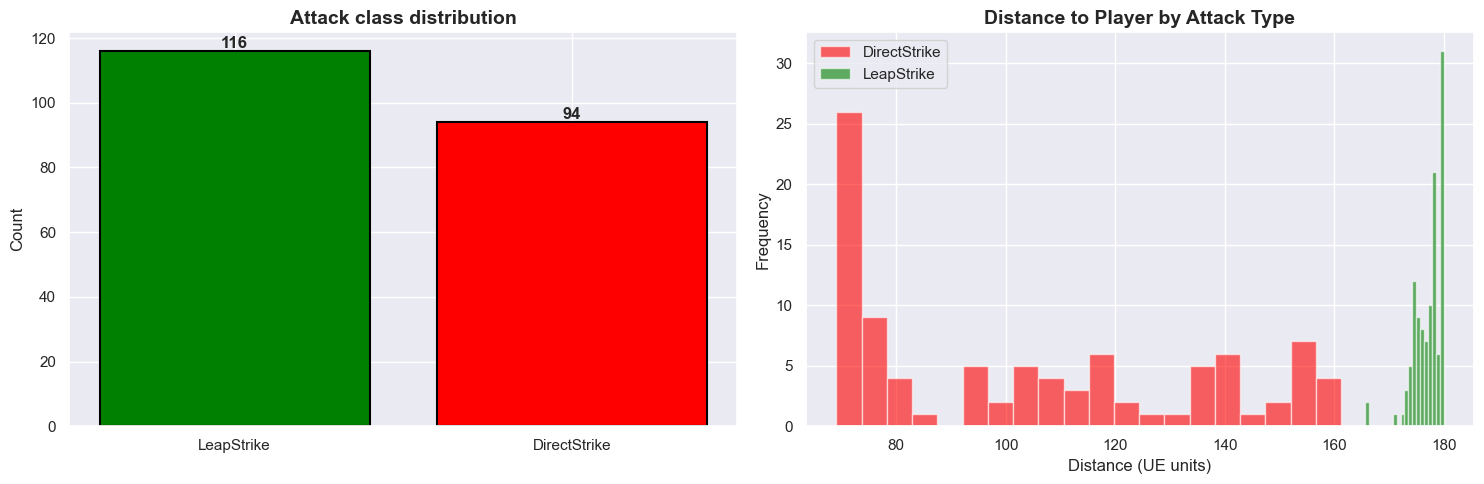

In [65]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

label_counts = attack_df["attack_label"].value_counts()
label_names  = {0: 'DirectStrike', 2: 'LeapStrike'}
labels = [label_names[i] for i in label_counts.index]
labels

axes[0].bar(labels,label_counts.values,color=['green', 'red'], edgecolor='black', linewidth=1.5)
axes[0].set_title("Attack class distribution",fontsize=14,fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

for label,name,color in [(0,'DirectStrike',"red"),(2,"LeapStrike","green")]:
    subset = attack_df[attack_df['attack_label'] == label]['distance_to_player']
    axes[1].hist(subset,bins=20,alpha=0.6,label=name,color=color,edgecolor='white')

axes[1].set_title("Distance to Player by Attack Type",fontsize=14,fontweight="bold")
axes[1].set_xlabel('Distance (UE units)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig("../images/eda_attack_distribution.png",dpi=100,bbox_inches='tight')
plt.show()

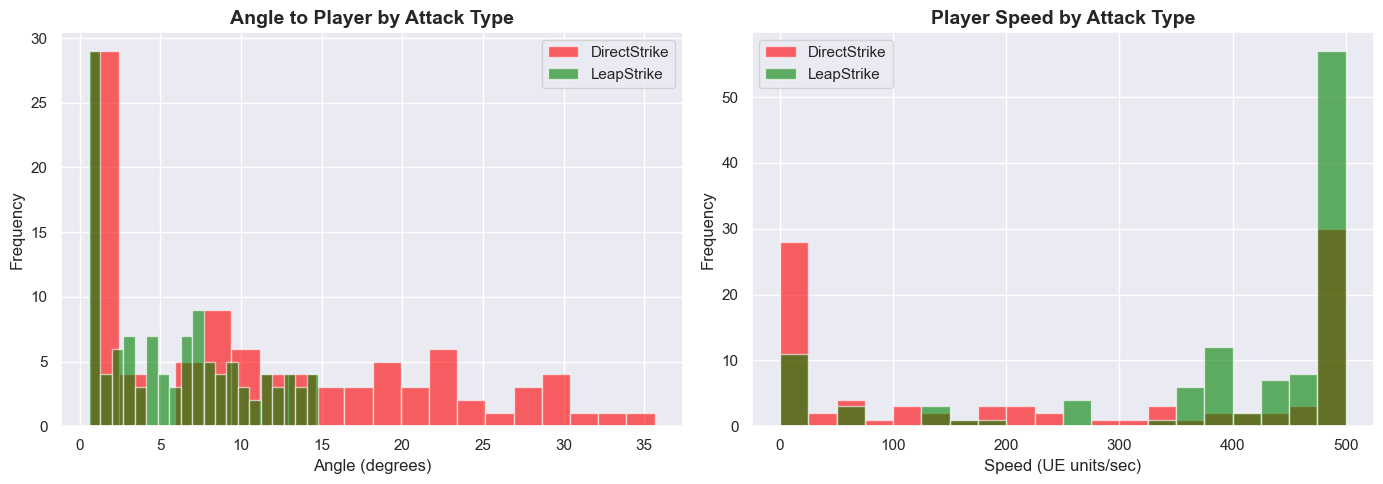

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: angle by attack type ---
# DirectStrike should have smaller angles (enemy faces player directly)
# LeapStrike should have more varied angles (player running away)
for label, name, color in [(0, 'DirectStrike', 'red'), (2, 'LeapStrike', 'green')]:
    subset = attack_df[attack_df['attack_label'] == label]['angle_to_player']
    axes[0].hist(subset, bins=20, alpha=0.6, label=name, color=color, edgecolor='white')

axes[0].set_title('Angle to Player by Attack Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Angle (degrees)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# --- Plot 2: player speed by attack type ---
# When player is running away (high speed) → LeapStrike
# When player is standing/near → DirectStrike
for label, name, color in [(0, 'DirectStrike', 'red'), (2, 'LeapStrike', 'green')]:
    subset = attack_df[attack_df['attack_label'] == label]['player_speed']
    axes[1].hist(subset, bins=20, alpha=0.6, label=name, color=color, edgecolor='white')

axes[1].set_title('Player Speed by Attack Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Speed (UE units/sec)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/eda_attack_features.png', dpi=100, bbox_inches='tight')
plt.show()

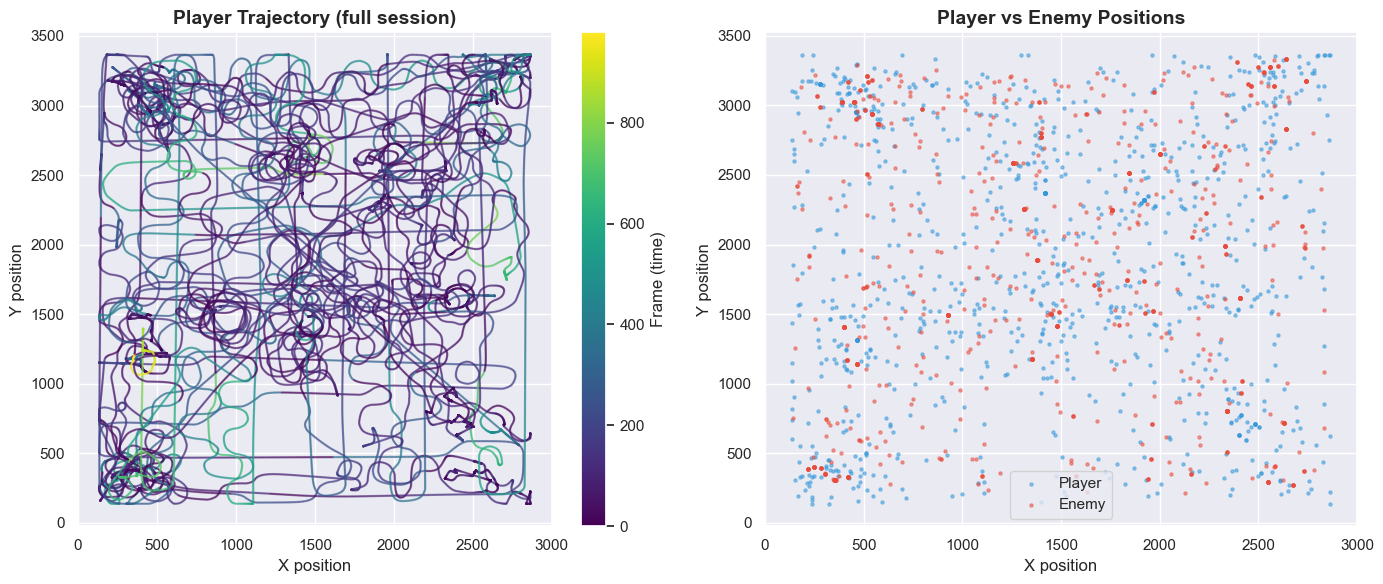

In [71]:
ig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: full player trajectory ---
# Shows the complete path the player took during the session
# Good coverage = model learns varied movements
axes[0].scatter(movement_df['player_x'], movement_df['player_y'],
                c=movement_df['frame'], cmap='viridis',
                s=0.5, alpha=0.5)
axes[0].set_title('Player Trajectory (full session)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('X position')
axes[0].set_ylabel('Y position')

# Color = time progression (dark=early, light=late)
sm = plt.cm.ScalarMappable(cmap='viridis',
     norm=plt.Normalize(movement_df['frame'].min(), movement_df['frame'].max()))
plt.colorbar(sm, ax=axes[0], label='Frame (time)')

# --- Plot 2: player vs enemy positions ---
# Shows how close the enemy tracked the player
sample = movement_df.iloc[::50]  # sample every 50 frames for clarity
axes[1].scatter(sample['player_x'], sample['player_y'],
                s=5, alpha=0.5, label='Player', color='#3498db')
axes[1].scatter(sample['enemy_x'], sample['enemy_y'],
                s=5, alpha=0.5, label='Enemy', color='#e74c3c')
axes[1].set_title('Player vs Enemy Positions', fontsize=14, fontweight='bold')
axes[1].set_xlabel('X position')
axes[1].set_ylabel('Y position')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/eda_trajectories.png', dpi=100, bbox_inches='tight')
plt.show()

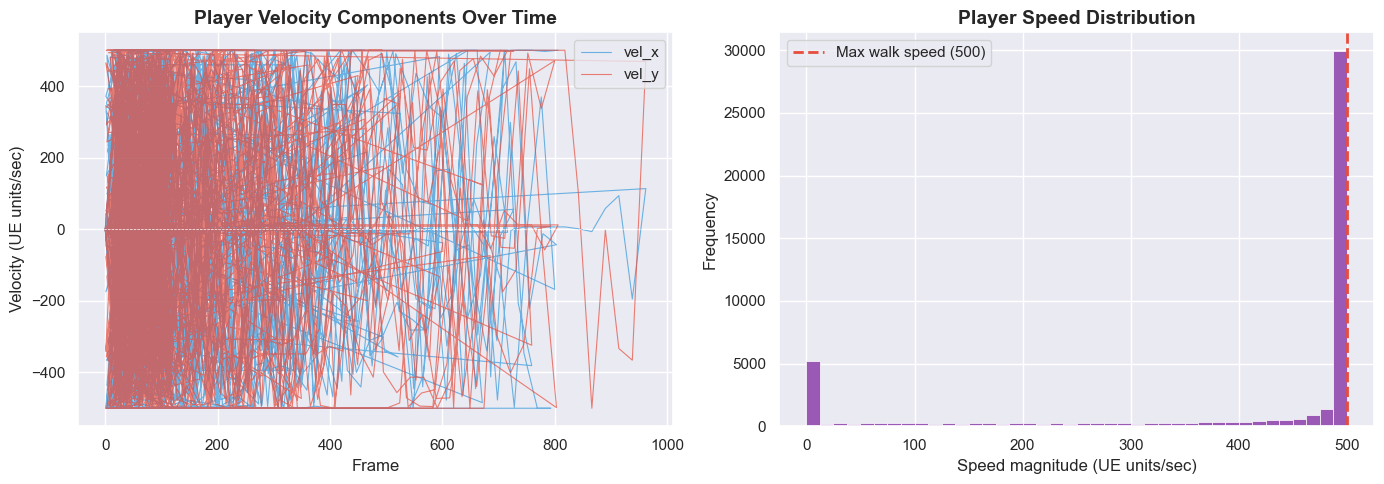


Frames where player is still (speed < 10): 5153 (10.9%)


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: velocity components over time ---
# Sample 2000 frames for readability
sample = movement_df.iloc[::24].head(2000)

axes[0].plot(sample['frame'], sample['player_vel_x'],
             alpha=0.7, label='vel_x', color='#3498db', linewidth=0.8)
axes[0].plot(sample['frame'], sample['player_vel_y'],
             alpha=0.7, label='vel_y', color='#e74c3c', linewidth=0.8)
axes[0].set_title('Player Velocity Components Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Velocity (UE units/sec)')
axes[0].legend()
axes[0].axhline(y=0, color='white', linewidth=0.5, linestyle='--')

# --- Plot 2: velocity magnitude distribution ---
# Shows how often the player was still vs moving
movement_df['player_speed'] = np.sqrt(
    movement_df['player_vel_x']**2 + movement_df['player_vel_y']**2
)

axes[1].hist(movement_df['player_speed'], bins=40,
             color='#9b59b6', edgecolor='white', linewidth=0.5)
axes[1].set_title('Player Speed Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Speed magnitude (UE units/sec)')
axes[1].set_ylabel('Frequency')

# Mark the max walk speed (500 UE units = configured in character)
axes[1].axvline(x=500, color='#e74c3c', linewidth=2,
                linestyle='--', label='Max walk speed (500)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/eda_velocities.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nFrames where player is still (speed < 10): "
      f"{(movement_df['player_speed'] < 10).sum()} "
      f"({(movement_df['player_speed'] < 10).mean()*100:.1f}%)")